# Evaluation of Experiments

In [7]:
import os
import json

import numpy as np
import pylab as plt
import yaml

from pathlib import Path

In [8]:
query_strategies = ['random', 'randomclust', 'entropy', 'leastconfidence', 'margin', 'coreset', 'badge', 'typiclust', 'alfamix', 'dropquery', 'falcun']
Q = {'random':'Random', 'randomclust': 'Random Clust', 'entropy':'Entropy', 'leastconfidence':'Least Confidence', 'margin':'Margin', 'coreset':'CoreSet', 'badge':'BADGE', 'typiclust':'TypiClust', 'alfamix':'AlfaMix', 'dropquery':'DropQuery', 'falcun':'FALCUN'}
seeds = ['seed_1', 'seed_2', 'seed_3']
results = {mn:{} for mn in query_strategies}
root_path = Path('/home/phahn/repositories/dal-toolbox/examples/active_learning/server_experiments/server_results/baselines_1/')

count = 0

for qs in query_strategies:
    paths = sorted(list(root_path.glob(qs+"/*")))
    for path in paths:
        if os.path.exists(path / 'results.json'):
            count += 1
            with open(path / 'results.json', 'r') as f:
                run_results = json.load(f)
            with open(path / '.hydra/config.yaml') as g:
                conf = yaml.load(g, Loader=yaml.FullLoader)

            results[qs][path.stem[-1]] = {'results': run_results, 'args': conf}
print(f"Number Runs: {count}/36.")

Number Runs: 33/36.


In [9]:
test_stats = {
    qs:{
        seed:{} for seed in seeds
        } for qs in query_strategies}

for qs, res in results.items():
    metrics = {}
    for seed, r in res.items():
        seed = 'seed_'+seed
        for i_cyc in ['cycle'+str(i) for i in range(20)]:
            cycle_results = r['results'][i_cyc]
            for met, val in cycle_results['test_stats'].items():
                if met not in test_stats[qs][seed]:
                    test_stats[qs][seed][met] = [val]
                else:
                    test_stats[qs][seed][met].append(val)

In [10]:
accs = {qs:[test_stats[qs][i_seed]['accuracy'] for i_seed in seeds if 'accuracy' in test_stats[qs][i_seed]] for qs in query_strategies}
rand_accs = [test_stats['random'][i_seed]['accuracy'] for i_seed in seeds if 'accuracy' in test_stats['random'][i_seed]]

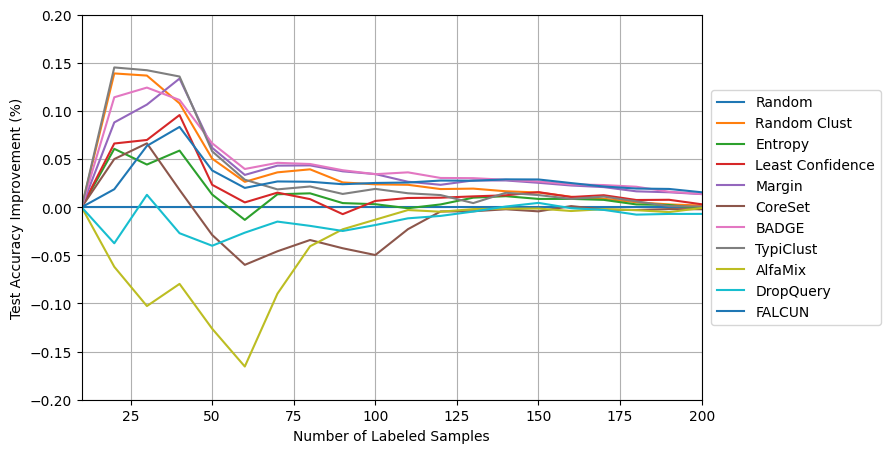

In [12]:
plt.figure(figsize=(8, 5))

x_ticks = [10+i*10 for i in range(20)]

for qs in query_strategies:
    plt.plot(x_ticks, np.mean(accs[qs], axis=0)-np.mean(rand_accs, axis=0), label=Q[qs])
lgd = plt.legend(bbox_to_anchor=[1.3, 0.5], loc='center right')
plt.grid(True)
plt.xlabel('Number of Labeled Samples')
plt.ylabel('Test Accuracy Improvement (%)')
plt.xlim((x_ticks[0], x_ticks[-1]))
plt.ylim(-0.2, 0.2)
#plt.show()
plt.savefig('./plots/dinov2_cifar10.png', bbox_extra_artists=(lgd,), bbox_inches='tight')